# Audio Duration Analysis

Analyze audio duration distribution for datasets in data/raw directory (supports wav and mp3 formats)

## 1. Import Libraries

In [1]:
import os
import wave
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict
import matplotlib
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from pydub import AudioSegment
import pandas as pd

# Set plot style
plt.style.use('default')
%matplotlib inline

## 2. Configuration - Dataset Names and Display Names

In [2]:
# Define dataset names (folder names)
DATASET_FOLDERS = [
    'ADReSS_merged',
    'ADReSS-M_merged',
    'ADReSSo_merged',
    'Pitt_merged',
    'Lu_merged'
]

# Define display names for plots (same order as DATASET_FOLDERS)
DATASET_DISPLAY_NAMES = [
    'ADReSS',
    'ADReSS-M',
    'ADReSSo',
    'Pitt',
    'Lu'
]

# Base directory for data
BASE_DIR = Path('../ad_detection/data/raw')

## 3. Define Utility Functions

In [3]:
def get_audio_duration(audio_path: str) -> float:
    """
    Get audio duration in seconds, supports wav and mp3 formats
    
    Args:
        audio_path: Audio file path
    
    Returns:
        Duration in seconds
    """
    try:
        if audio_path.lower().endswith('.wav'):
            with wave.open(audio_path, 'r') as wav_file:
                frames = wav_file.getnframes()
                rate = wav_file.getframerate()
                duration = frames / float(rate)
                return duration
        elif audio_path.lower().endswith('.mp3'):
            audio = AudioSegment.from_mp3(audio_path)
            duration = len(audio) / 1000.0  # pydub returns milliseconds
            return duration
        else:
            return 0.0
    except Exception as e:
        print(f"Error reading {audio_path}: {e}")
        return 0.0


def analyze_dataset(dataset_path: str) -> List[float]:
    """
    Analyze duration of all audio files in dataset (non-recursive)
    
    Args:
        dataset_path: Dataset path
    
    Returns:
        List of durations in seconds
    """
    durations = []
    dataset_path = Path(dataset_path)
    
    # Check Control and Dementia subdirectories
    for subdir in ['Control', 'Dementia']:
        subdir_path = dataset_path / subdir
        if subdir_path.exists():
            for file_path in subdir_path.iterdir():
                if file_path.is_file() and file_path.suffix.lower() in ['.wav', '.mp3']:
                    duration = get_audio_duration(str(file_path))
                    if duration > 0:
                        durations.append(duration)
    
    return durations


def print_statistics(dataset_name: str, durations: List[float]) -> None:
    """
    Print dataset statistics
    
    Args:
        dataset_name: Dataset name
        durations: List of durations
    """
    if not durations:
        print(f"\n{dataset_name}: No valid data")
        return
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"File count: {len(durations)}")
    print(f"Max duration: {max(durations):.2f} sec ({max(durations)/60:.2f} min)")
    print(f"Min duration: {min(durations):.2f} sec")
    print(f"Mean duration: {np.mean(durations):.2f} sec ({np.mean(durations)/60:.2f} min)")
    print(f"Median duration: {np.median(durations):.2f} sec")
    print(f"Std deviation: {np.std(durations):.2f} sec")
    print(f"Total duration: {sum(durations):.2f} sec ({sum(durations)/60:.2f} min)")

## 4. Analyze All Datasets

In [4]:
print("Starting audio dataset analysis...")
print(f"Data directory: {BASE_DIR.absolute()}")

# Store results
dataset_stats = {}

# Analyze each dataset
for folder_name, display_name in zip(DATASET_FOLDERS, DATASET_DISPLAY_NAMES):
    dataset_path = BASE_DIR / folder_name
    
    if not dataset_path.exists():
        print(f"\nWarning: {folder_name} does not exist, skipping...")
        continue
    
    print(f"\nAnalyzing: {display_name} ({folder_name})...")
    durations = analyze_dataset(str(dataset_path))
    dataset_stats[display_name] = durations
    
    # Print statistics
    print_statistics(display_name, durations)

print(f"\n\n{'='*60}")
print(f"Analysis complete! Analyzed {len(dataset_stats)} datasets")
print(f"{'='*60}")

Starting audio dataset analysis...
Data directory: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/dataset_analysis/../ad_detection/data/raw

Analyzing: ADReSS (ADReSS_merged)...

Dataset: ADReSS
File count: 156
Max duration: 268.48 sec (4.47 min)
Min duration: 26.06 sec
Mean duration: 75.30 sec (1.26 min)
Median duration: 70.05 sec
Std deviation: 38.26 sec
Total duration: 11746.98 sec (195.78 min)

Analyzing: ADReSS-M (ADReSS-M_merged)...

Dataset: ADReSS-M
File count: 237
Max duration: 268.49 sec (4.47 min)
Min duration: 22.29 sec
Mean duration: 76.89 sec (1.28 min)
Median duration: 70.48 sec
Std deviation: 37.41 sec
Total duration: 18223.02 sec (303.72 min)

Analyzing: ADReSSo (ADReSSo_merged)...
Error reading ../ad_detection/data/raw/ADReSSo_merged/Control/adrso300.wav: unknown format: 3
Error reading ../ad_detection/data/raw/ADReSSo_merged/Dementia/adrso063.wav: unknown format: 3
Error reading ../ad_detection/data/raw/ADReS

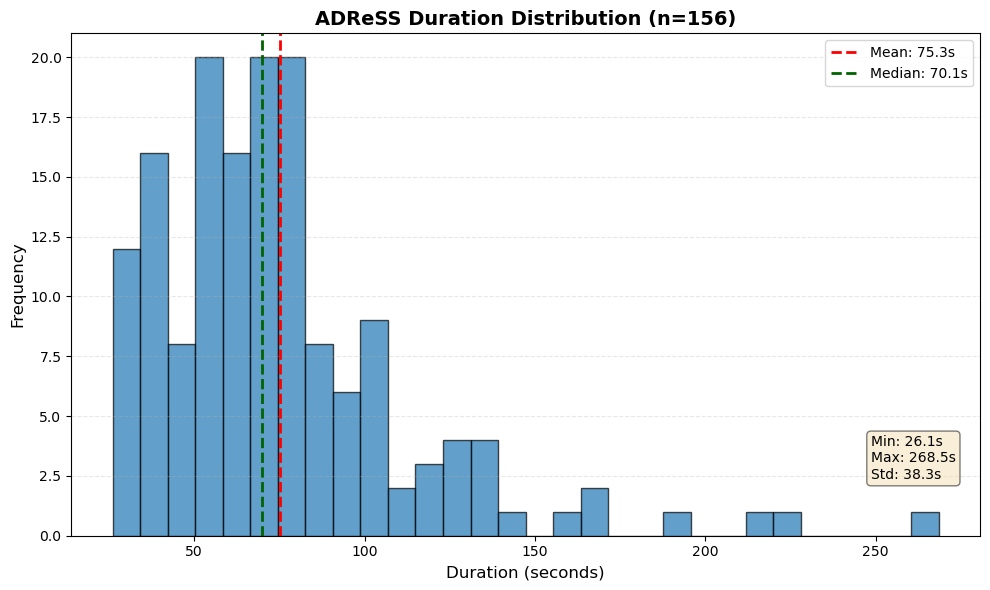

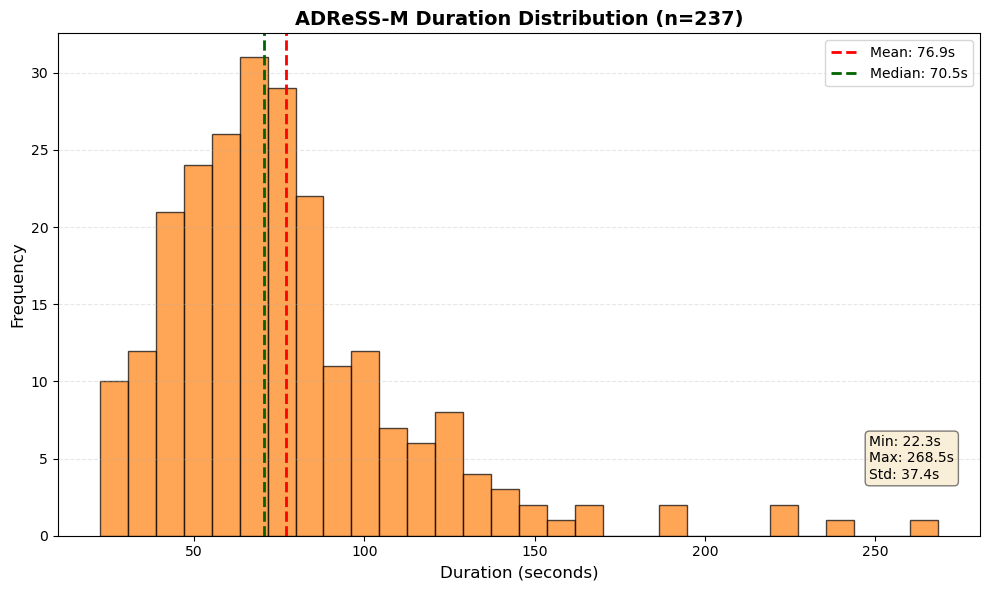

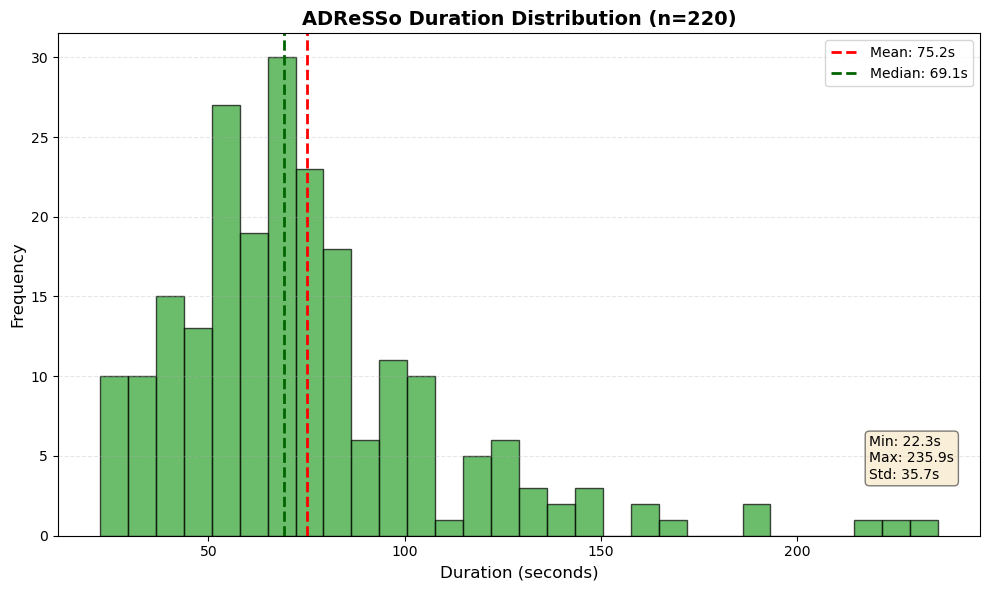

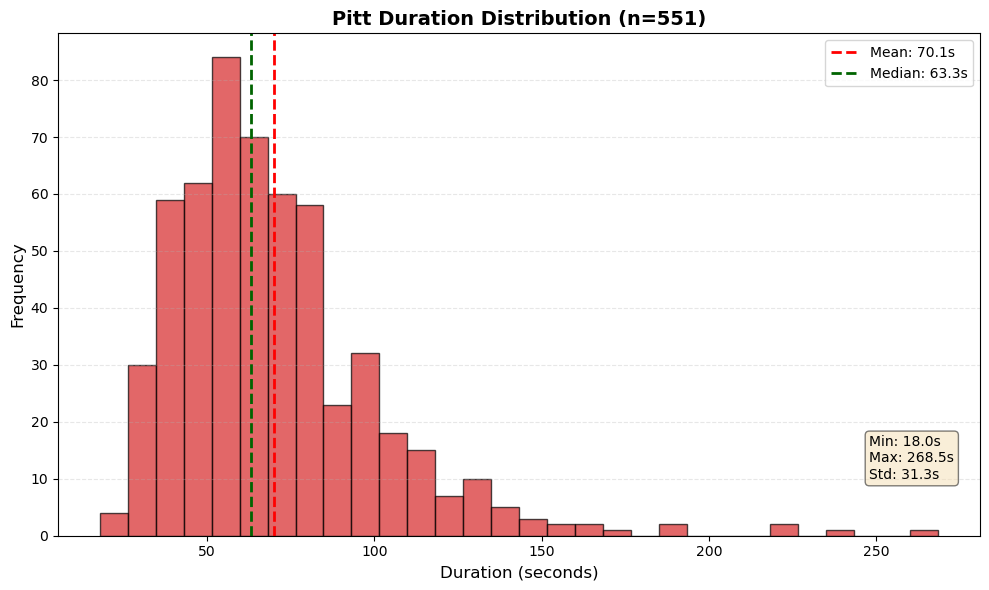

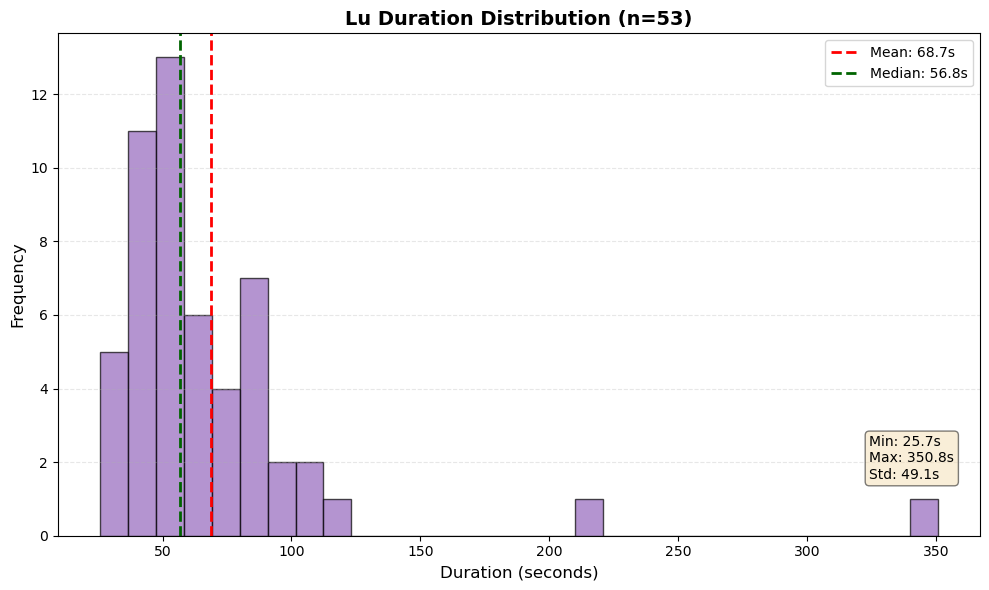

In [5]:
# Define colors for each dataset
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Generate individual histogram for each dataset
for idx, display_name in enumerate(DATASET_DISPLAY_NAMES):
    if display_name not in dataset_stats or not dataset_stats[display_name]:
        print(f"Skipping {display_name}: No data available")
        continue
    
    durations = dataset_stats[display_name]
    color = COLORS[idx]
    
    # Create individual figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot histogram
    ax.hist(durations, bins=30, color=color, alpha=0.7, edgecolor='black')
    
    # Add mean and median lines
    mean_val = np.mean(durations)
    median_val = np.median(durations)
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}s')
    ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}s')
    
    # Styling
    ax.set_xlabel('Duration (seconds)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{display_name} Duration Distribution (n={len(durations)})', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add statistics text box
    stats_text = f'Min: {min(durations):.1f}s\nMax: {max(durations):.1f}s\nStd: {np.std(durations):.1f}s'
    ax.text(0.88, 0.2, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()

## 6. Summary Statistics Table

In [6]:
# Create summary table using the predefined order
summary_data = []
for display_name in DATASET_DISPLAY_NAMES:
    if display_name in dataset_stats and dataset_stats[display_name]:
        durations = dataset_stats[display_name]
        summary_data.append({
            'Dataset': display_name,
            'File Count': len(durations),
            'Min Duration (s)': f"{min(durations):.2f}",
            'Max Duration (s)': f"{max(durations):.2f}",
            'Mean Duration (s)': f"{np.mean(durations):.2f}",
            'Mean Duration (min)': f"{np.mean(durations)/60:.2f}",
            'Median (s)': f"{np.median(durations):.2f}",
            'Std Dev (s)': f"{np.std(durations):.2f}",
            'Total Duration (min)': f"{sum(durations)/60:.2f}"
        })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("Summary Statistics for All Datasets")
print("="*100)
print(df_summary.to_string(index=False))

# Save to CSV
df_summary.to_csv('audio_duration_summary.csv', index=False, encoding='utf-8-sig')
print("\nSummary table saved to: audio_duration_summary.csv")


Summary Statistics for All Datasets
 Dataset  File Count Min Duration (s) Max Duration (s) Mean Duration (s) Mean Duration (min) Median (s) Std Dev (s) Total Duration (min)
  ADReSS         156            26.06           268.48             75.30                1.26      70.05       38.26               195.78
ADReSS-M         237            22.29           268.49             76.89                1.28      70.48       37.41               303.72
 ADReSSo         220            22.35           235.86             75.16                1.25      69.12       35.71               275.60
    Pitt         551            18.00           268.48             70.06                1.17      63.29       31.26               643.39
      Lu          53            25.73           350.76             68.73                1.15      56.77       49.14                60.71

Summary table saved to: audio_duration_summary.csv
